# Anomaly Detection

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *


The dataset contains two features - 
   * throughput (mb/s) and 
   * latency (ms) of response of each server.

While your servers were operating, you collected $m=307$ examples of how they were behaving, and thus have an unlabeled dataset $\{x^{(1)}, \ldots, x^{(m)}\}$. 
* You suspect that the vast majority of these examples are “normal” (non-anomalous) examples of the servers operating normally, but there might also be some examples of servers acting anomalously within this dataset.


## 1. Load Dataset

In [2]:
# Load the dataset
X_train, X_val, y_val = load_data()

In [3]:
# Display the first five elements of X_train
print("The first 5 elements of X_train are:\n", X_train[:5])  

The first 5 elements of X_train are:
 [[13.04681517 14.74115241]
 [13.40852019 13.7632696 ]
 [14.19591481 15.85318113]
 [14.91470077 16.17425987]
 [13.57669961 14.04284944]]


In [4]:
# Display the first five elements of X_val
print("The first 5 elements of X_val are\n", X_val[:5])  

The first 5 elements of X_val are
 [[15.79025979 14.9210243 ]
 [13.63961877 15.32995521]
 [14.86589943 16.47386514]
 [13.58467605 13.98930611]
 [13.46404167 15.63533011]]


In [5]:
# Display the first five elements of y_val
print("The first 5 elements of y_val are\n", y_val[:5])  

The first 5 elements of y_val are
 [0 0 0 0 0]


In [6]:
print ('The shape of X_train is:', X_train.shape)
print ('The shape of X_val is:', X_val.shape)
print ('The shape of y_val is: ', y_val.shape)

The shape of X_train is: (307, 2)
The shape of X_val is: (307, 2)
The shape of y_val is:  (307,)


## 2. Visualize Data

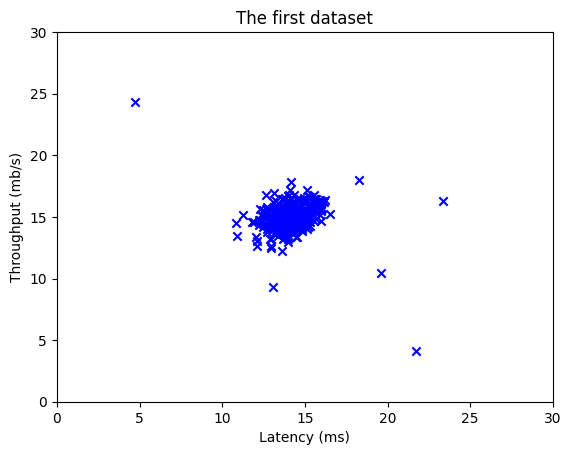

In [7]:
# Create a scatter plot of the data. To change the markers to blue "x",
# we used the 'marker' and 'c' parameters
plt.scatter(X_train[:, 0], X_train[:, 1], marker='x', c='b') 

# Set the title
plt.title("The first dataset")
# Set the y-axis label
plt.ylabel('Throughput (mb/s)')
# Set the x-axis label
plt.xlabel('Latency (ms)')
# Set axis range
plt.axis([0, 30, 0, 30])
plt.show()

# Gaussian Distribution

## 1. One Feature — 1D Gaussian

For a single feature $x$, the Gaussian probability density is:

$$
p(x)=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right)
$$

Where:

- $\mu$ = mean
- $\sigma^2$ = variance
- $x$ = feature value

### Two main parts

$$
p(x)=
\underbrace{
\frac{1}{\sqrt{2\pi\sigma^2}}
}_{\text{Normalization}}
\times
\underbrace{
\exp\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right)
}_{\text{Distance / Shape}}
$$

The distance-related term is:

$$
\frac{(x-\mu)^2}{\sigma^2}
$$

It measures how far $x$ is from the mean relative to the variance.

---

## 2. Multiple Features — Multivariate Gaussian

For $k$ features, $x$ becomes a vector:

$$
x=
\begin{bmatrix}
x_1\\
x_2\\
\vdots\\
x_k
\end{bmatrix}
$$

and the mean becomes:

$$
\mu=
\begin{bmatrix}
\mu_1\\
\mu_2\\
\vdots\\
\mu_k
\end{bmatrix}
$$

Instead of a single variance $\sigma^2$, we use a **covariance matrix** $\Sigma$.

The multivariate Gaussian is:

$$
p(x)=
\frac{1}
{(2\pi)^{k/2}|\Sigma|^{1/2}}
\exp\left(
-\frac{1}{2}
(x-\mu)^T
\Sigma^{-1}
(x-\mu)
\right)
$$

Where:

- $k$ = number of features
- $\mu$ = mean vector
- $\Sigma$ = covariance matrix
- $|\Sigma|$ = determinant of covariance matrix
- $\Sigma^{-1}$ = inverse covariance matrix

---

## 3. Covariance Matrix

For two features:

$$
\Sigma=
\begin{bmatrix}
\sigma_1^2 & \operatorname{cov}(x_1,x_2)\\
\operatorname{cov}(x_1,x_2) & \sigma_2^2
\end{bmatrix}
$$

- Diagonal → variance of each feature
- Off-diagonal → covariance between features

The covariance matrix allows the Gaussian to consider **both feature spread and relationships between features**.

---

## 4. Determinant vs Inverse Covariance

The multivariate Gaussian has two important parts:

### Normalization

$$
\frac{1}
{(2\pi)^{k/2}|\Sigma|^{1/2}}
$$

The determinant $|\Sigma|$ represents the **overall spread/volume** of the distribution.

$$
\boxed{
|\Sigma| \rightarrow \text{overall spread / normalization}
}
$$

### Distance

$$
(x-\mu)^T\Sigma^{-1}(x-\mu)
$$

The inverse covariance matrix accounts for:

- Variance of each feature
- Correlation between features

$$
\boxed{
\Sigma^{-1}
\rightarrow
\text{distance from mean + feature correlations}
}
$$

---

## 5. One Feature vs Multiple Features

| One Feature | Multiple Features |
|---|---|
| Variance $\sigma^2$ | Covariance matrix $\Sigma$ |
| $\frac{(x-\mu)^2}{\sigma^2}$ | $(x-\mu)^T\Sigma^{-1}(x-\mu)$ |
| Scalar calculation | Matrix calculation |
| No feature correlation | Can account for feature correlation |

### Main idea

The multivariate Gaussian is simply the **generalization of the 1D Gaussian**:

$$
\boxed{
\sigma^2 \rightarrow \Sigma
}
$$

$$
\boxed{
\frac{(x-\mu)^2}{\sigma^2}
\rightarrow
(x-\mu)^T\Sigma^{-1}(x-\mu)
}
$$

So remember:

> **Determinant → overall spread / normalization**

> **Inverse covariance → distance / feature relationships**


“In a multivariate Gaussian, the covariance matrix captures both the variance of each feature and the correlations between features. The determinant of the covariance matrix is used in the normalization term because it represents the overall spread or volume of the distribution. The inverse covariance matrix is used in the distance term to measure how far a data point is from the mean while accounting for feature variance and correlations. A low resulting probability indicates a potential anomaly.”

In [10]:
def estimate_gaussian(X): 
    """
    Calculates mean and variance of all features 
    in the dataset
    
    Args:
        X (ndarray): (m, n) Data matrix
    
    Returns:
        mu (ndarray): (n,) Mean of all features
        var (ndarray): (n,) Variance of all features
    """

    m, n = X.shape
   
    mu = np.mean(X, axis=0)
    
    var =np.mean((X-mu)**2 , axis=0)
        
    return mu, var

In [11]:
# Estimate mean and variance of each feature
mu, var = estimate_gaussian(X_train)              

print("Mean of each feature:", mu)
print("Variance of each feature:", var)


Mean of each feature: [14.11222578 14.99771051]
Variance of each feature: [1.83263141 1.70974533]


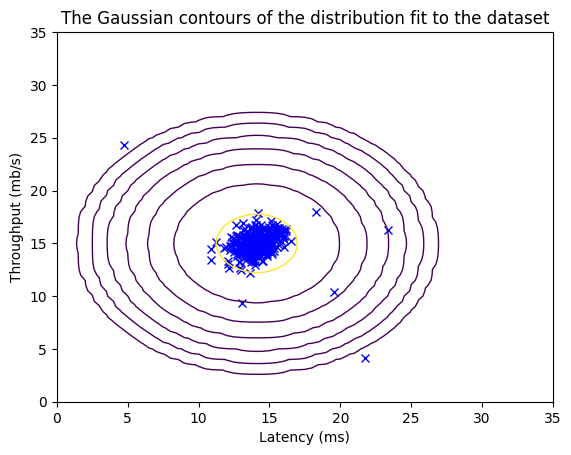

In [12]:
# Returns the density of the multivariate normal
# at each data point (row) of X_train
p = multivariate_gaussian(X_train, mu, var)

#Plotting code 
visualize_fit(X_train, mu, var)

## 3. Selecting the threshold $\epsilon$

Now that you have estimated the Gaussian parameters, you can investigate which examples have a very high probability given this distribution and which examples have a very low probability.  

* The low probability examples are more likely to be the anomalies in our dataset. 
* One way to determine which examples are anomalies is to select a threshold based on a cross validation set. 

In this section, you will complete the code in `select_threshold` to select the threshold $\varepsilon$ using the $F_1$ score on a cross validation set.

* For this, we will use a cross validation set
$\{(x_{\rm cv}^{(1)}, y_{\rm cv}^{(1)}),\ldots, (x_{\rm cv}^{(m_{\rm cv})}, y_{\rm cv}^{(m_{\rm cv})})\}$, where the label $y=1$ corresponds to an anomalous example, and $y=0$ corresponds to a normal example. 
* For each cross validation example, we will compute $p(x_{\rm cv}^{(i)})$. The vector of all of these probabilities $p(x_{\rm cv}^{(1)}), \ldots, p(x_{\rm cv}^{(m_{\rm cv})})$ is passed to `select_threshold` in the vector `p_val`. 
* The corresponding labels $y_{\rm cv}^{(1)}, \ldots, y_{\rm cv}^{(m_{\rm cv})}$ are passed to the same function in the vector `y_val`.

In [17]:
def select_threshold(y_val, p_val):

    best_epsilon = 0
    best_F1 = 0

    step_size = (max(p_val) - min(p_val)) / 1000

    for epsilon in np.arange(min(p_val), max(p_val), step_size):

        y_pred = p_val < epsilon

        tp = np.sum(y_pred & (y_val == 1))
        fn = np.sum(~y_pred & (y_val == 1))
        fp = np.sum(y_pred & (y_val == 0))

        # Avoid division by zero
        if tp + fp == 0:
            prec = 0
        else:
            prec = tp / (tp + fp)

        if tp + fn == 0:
            rec = 0
        else:
            rec = tp / (tp + fn)

        if prec + rec == 0:
            F1 = 0
        else:
            F1 = 2 * prec * rec / (prec + rec)

        if F1 > best_F1:
            best_F1 = F1
            best_epsilon = epsilon

    return best_epsilon, best_F1

In [18]:
p_val = multivariate_gaussian(X_val, mu, var)
epsilon, F1 = select_threshold(y_val, p_val)

print('Best epsilon found using cross-validation: %e' % epsilon)
print('Best F1 on Cross Validation Set: %f' % F1)

Best epsilon found using cross-validation: 8.990853e-05
Best F1 on Cross Validation Set: 0.875000


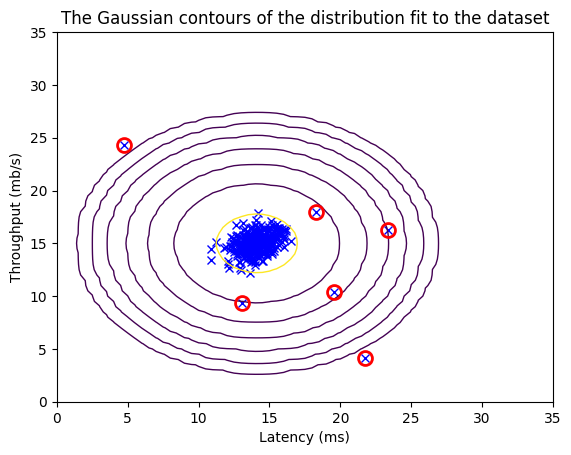

In [19]:
# Find the outliers in the training set 
outliers = p < epsilon

# Visualize the fit
visualize_fit(X_train, mu, var)

# Draw a red circle around those outliers
plt.plot(X_train[outliers, 0], X_train[outliers, 1], 'ro',
         markersize= 10,markerfacecolor='none', markeredgewidth=2)

## High dimensional dataset


In [20]:
# load the dataset
X_train_high, X_val_high, y_val_high = load_data_multi()

In [21]:
print ('The shape of X_train_high is:', X_train_high.shape)
print ('The shape of X_val_high is:', X_val_high.shape)
print ('The shape of y_val_high is: ', y_val_high.shape)

The shape of X_train_high is: (1000, 11)
The shape of X_val_high is: (100, 11)
The shape of y_val_high is:  (100,)


In [22]:
# Apply the same steps to the larger dataset

# Estimate the Gaussian parameters
mu_high, var_high = estimate_gaussian(X_train_high)

# Evaluate the probabilites for the training set
p_high = multivariate_gaussian(X_train_high, mu_high, var_high)

# Evaluate the probabilites for the cross validation set
p_val_high = multivariate_gaussian(X_val_high, mu_high, var_high)

# Find the best threshold
epsilon_high, F1_high = select_threshold(y_val_high, p_val_high)

print('Best epsilon found using cross-validation: %e'% epsilon_high)
print('Best F1 on Cross Validation Set:  %f'% F1_high)
print('# Anomalies found: %d'% sum(p_high < epsilon_high))

Best epsilon found using cross-validation: 1.377229e-18
Best F1 on Cross Validation Set:  0.615385
# Anomalies found: 117
